In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import homogeneity_completeness_v_measure, silhouette_score


df = pd.read_csv('../dataset/iris.csv')
df.drop('Id', axis=1, inplace=True)
# raname comlumn Sperices to variety
df.rename(columns={'Species': 'variety'}, inplace=True)
df


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,variety
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [2]:
d = {v:i for i, v in enumerate(df['variety'].unique())}
df = df.replace(d)

X = df.drop(['variety'], axis='columns')
y = df['variety']

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)


C:\Users\marco\AppData\Local\Temp\ipykernel_74076\1399047929.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(d)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


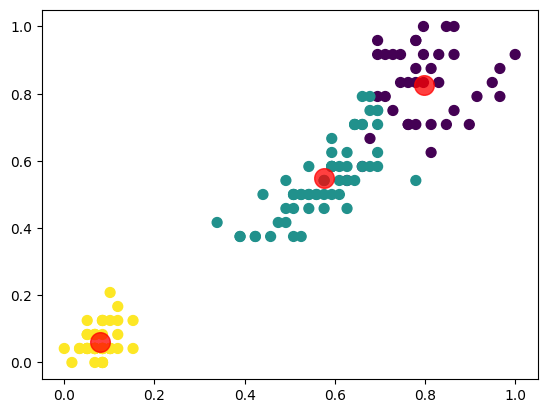

In [4]:
# plot the clusters
y_kmeans = kmeans.predict(X)
plt.scatter(X[:, 2], X[:, 3], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 2], centers[:, 3], c='red', s=200, alpha=0.75)
plt.show()

In [8]:

#print(kmeans.inertia_)
print(kmeans.cluster_centers_)
print(kmeans.labels_)
print(homogeneity_completeness_v_measure(y, kmeans.labels_))
print('Silhouette = ',silhouette_score(X,kmeans.labels_))

df['cluster'] = kmeans.labels_
df


[[0.70726496 0.4508547  0.79704476 0.82478632]
 [0.44125683 0.30737705 0.57571548 0.54918033]
 [0.19611111 0.59083333 0.07864407 0.06      ]]
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0
 0 1]
(0.7364192881252849, 0.7474865805095326, 0.7419116631817838)
Silhouette =  0.5043188549150884


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,variety,cluster
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0
146,6.3,2.5,5.0,1.9,2,1
147,6.5,3.0,5.2,2.0,2,0
148,6.2,3.4,5.4,2.3,2,0


In [10]:
# voglio cambiare la colonna cluster i 2 divenato 0 e i 0 diventato 2
df['cluster'] = df['cluster'].replace({2: 0, 0: 2})
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,variety,cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2
146,6.3,2.5,5.0,1.9,2,1
147,6.5,3.0,5.2,2.0,2,2
148,6.2,3.4,5.4,2.3,2,2


In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(df['variety'],df['cluster'])

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0, 14, 36]])

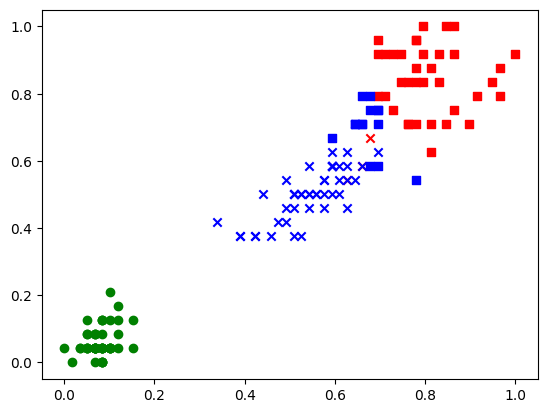

In [12]:
predictions = kmeans.labels_
colors = np.array(['red', 'blue', 'green'])
markers = ['o', 'x', 's']
for i in range(len(X)):
    plt.scatter(X[i,2], X[i,3], marker=markers[y[i]], color=colors[predictions[i]])
plt.show()


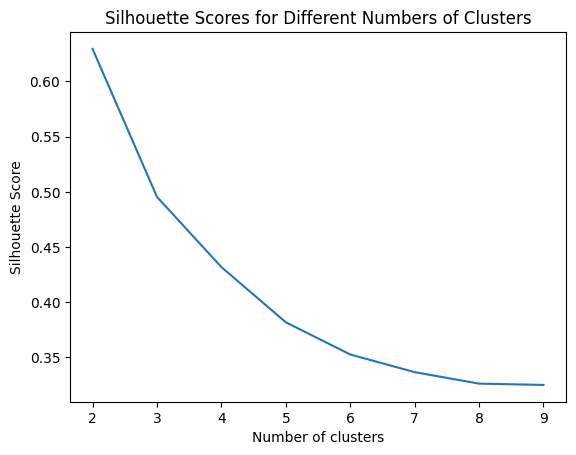

In [24]:
# voglio provare diversi numeri di cluster e vedere come cambia la silhouette
# salvo i risultati in una lista e poi li plotto

silhouettes = []
v = []



for n_clusters in range(2, 10):

    p_silhouettes = []
    p_v = []
    for _ in range(100):
        kmeans = KMeans(n_clusters=n_clusters)
        kmeans.fit(X)
        y_kmeans = kmeans.predict(X)
        silhouette = silhouette_score(X, y_kmeans)
        p_silhouettes.append(silhouette)
        p_v.append(homogeneity_completeness_v_measure(y, kmeans.labels_)[2])
    silhouettes.append(np.mean(p_silhouettes))
    v.append(np.mean(p_v))


plt.plot(range(2, 10), silhouettes)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
#plt.ylabel('V Score')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.show()

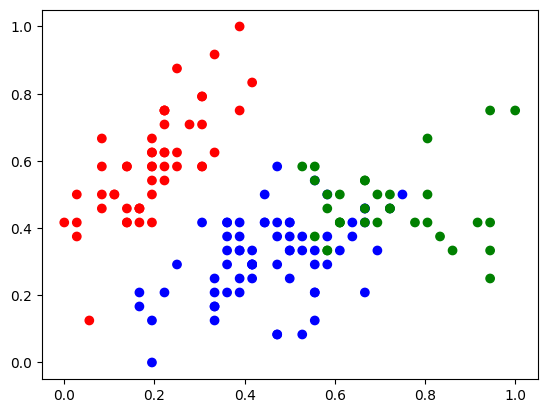

In [25]:
clusters = AgglomerativeClustering(n_clusters=3, linkage='average').fit(X)
predictions = clusters.labels_
colors = np.array(['red', 'blue','green'])
plt.scatter(X[:, 0], X[:, 1], color=colors[predictions])
plt.show()


In [26]:
print(homogeneity_completeness_v_measure(y, clusters.labels_))
print('Silhouette = ',silhouette_score(X,clusters.labels_))

(0.7697177990193531, 0.7982832930540932, 0.7837403461384024)
Silhouette =  0.5043490792923953


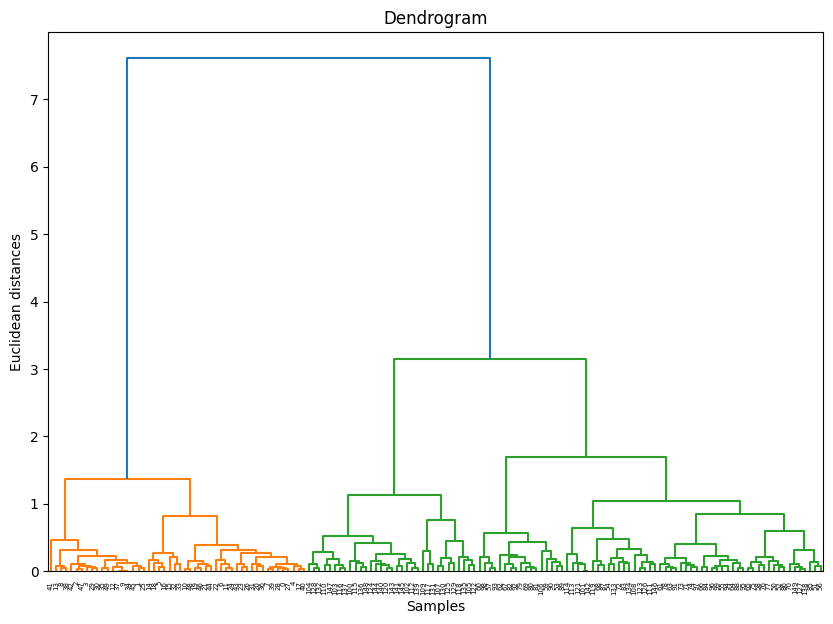

In [27]:
# visualizza dengrogramma
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
plt.show()

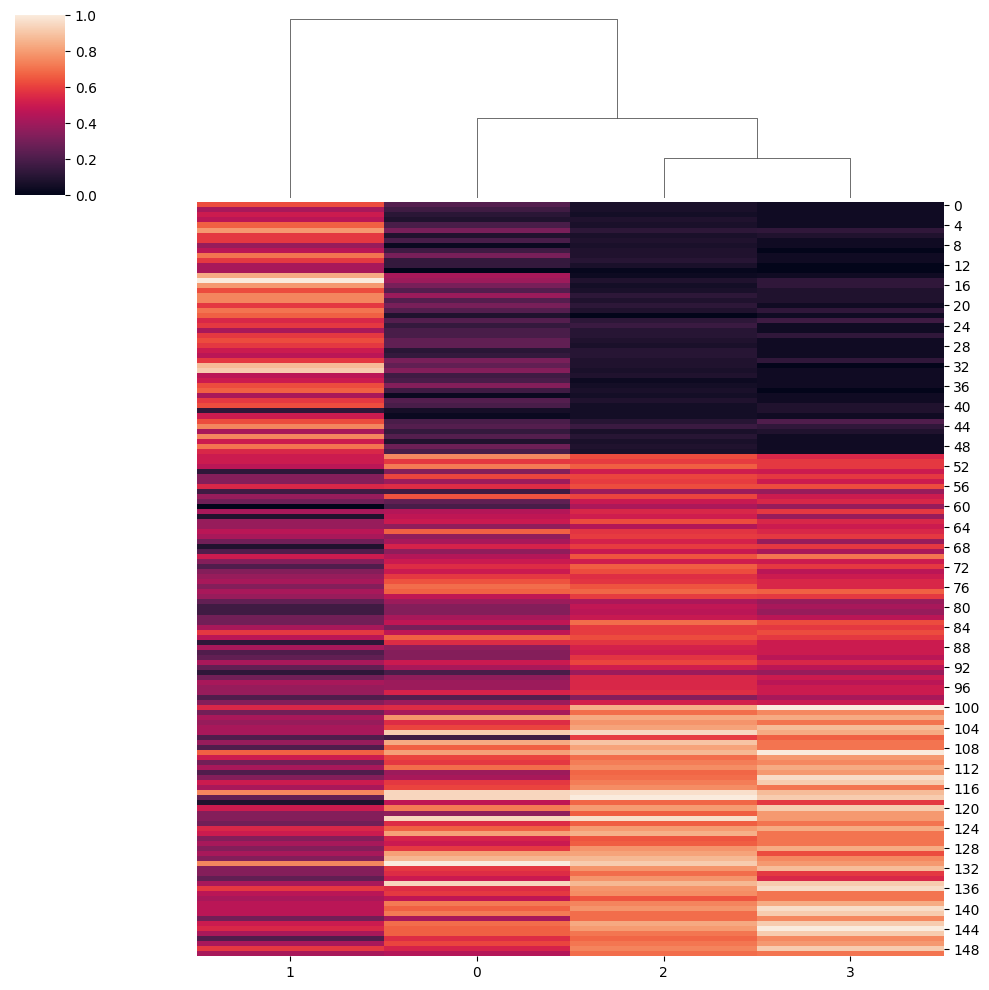

In [10]:
import seaborn as sns
sns.clustermap(X, row_cluster=False)
plt.show()
